/var/folders/yy/wmmdvn295kn5535yf3g57f2m0000gn/T/ipykernel_19108/3985681321.py:24: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  final = pd.concat([process_file(f"csv_log/P{i}_baseline.csv", f"P{i}") for i in range(1,13)])


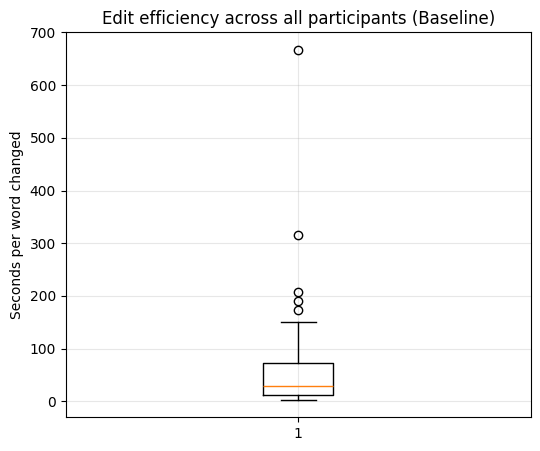

count     88.000000
unique    85.000000
top        3.428571
freq       2.000000
Name: sec_per_word, dtype: float64
평균: 56.48253143777288
중앙값: 30.055555555555557
표준편차: 85.88542569901041
최솟값: 3.0
최댓값: 667.0


In [34]:
import pandas as pd, ast
from difflib import ndiff
import matplotlib.pyplot as plt

def process_file(path, pid):
    df = pd.read_csv(path)
    df["details"] = df["details"].apply(lambda x: ast.literal_eval(x) if pd.notnull(x) else {})
    df["iid"] = df.apply(lambda r: r["details"].get("instanceId") if "add.instance" in r["event"] else r["details"].get("nodeId"), axis=1)
    df["ts"] = pd.to_datetime(df["timestamp"], format="%H:%M:%S")

    recs, prev_label, prev_t = [], {}, {}
    for _, row in df[df["iid"].notnull()].sort_values("ts").iterrows():
        iid, ev, det, t = row["iid"], row["event"], row["details"], row["ts"]
        if "add.instance" in ev: 
            prev_label[iid], prev_t[iid] = det.get("instanceLabel"), t
        if "edit" in ev and iid in prev_label:
            new, old = det.get("newLabel"), prev_label[iid]
            diff = [d for d in ndiff(old.split(), new.split()) if d[0] in "+-"]
            recs.append([(t-prev_t[iid]).total_seconds(), len(diff)])
            prev_label[iid], prev_t[iid] = new, t
    return pd.DataFrame(recs, columns=["duration_sec","words_changed"])

# ---- 전체 참가자 처리 ----
final = pd.concat([process_file(f"csv_log/P{i}_baseline.csv", f"P{i}") for i in range(1,13)])

# ---- 단어당 소요 시간 ----
final["sec_per_word"] = final["duration_sec"] / final["words_changed"]

# ---- Boxplot ----
plt.figure(figsize=(6,5))
plt.boxplot(final["sec_per_word"].dropna())
plt.ylabel("Seconds per word changed")
plt.title("Edit efficiency across all participants (Baseline)")
plt.grid(alpha=0.3)
plt.show()

# ---- 통계값 출력 ----
desc = final["sec_per_word"].describe(percentiles=[.25, .5, .75])
print(desc)

print("평균:", final["sec_per_word"].mean())
print("중앙값:", final["sec_per_word"].median())
print("표준편차:", final["sec_per_word"].std())
print("최솟값:", final["sec_per_word"].min())
print("최댓값:", final["sec_per_word"].max())


/var/folders/yy/wmmdvn295kn5535yf3g57f2m0000gn/T/ipykernel_19108/4254597813.py:58: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  baseline_all = pd.concat([process_baseline(f"csv_log/P{i}_baseline.csv", f"P{i}") for i in range(1,13)])


<Figure size 700x500 with 0 Axes>

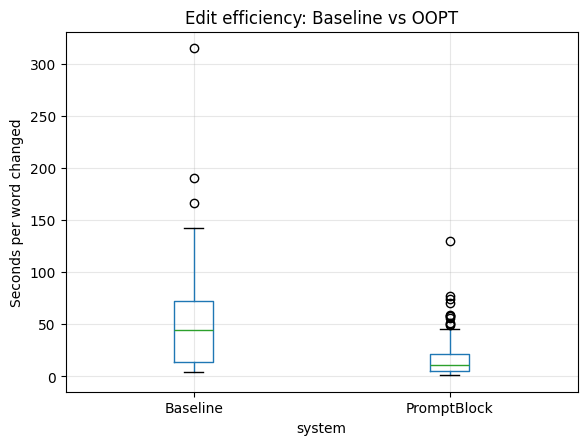

             count       mean        std  min        25%    50%     75%    max
system                                                                        
Baseline      47.0  59.134090  60.456341  4.5  13.693182  44.75  72.625  315.0
PromptBlock  130.0  17.438462  18.922938  1.0   5.250000  11.00  21.750  130.0


In [35]:
import pandas as pd, ast, matplotlib.pyplot as plt

# -------------------------
# Baseline (이전 버전 그대로 사용)
# -------------------------
def process_baseline(path, pid):
    df = pd.read_csv(path)
    df["details"] = df["details"].apply(lambda x: ast.literal_eval(x) if pd.notnull(x) else {})
    df["ts"] = pd.to_datetime(df["timestamp"], format="%H:%M:%S")

    edits = df[df["event"]=="baselineboard.node.edit"].copy().sort_values("ts")
    recs = []
    prev_text, prev_time = {}, {}

    for _, row in edits.iterrows():
        det = row["details"]
        node = det.get("nodeId")
        new_text = det.get("newLabel")
        t = row["ts"]

        if node in prev_text:
            old = prev_text[node]
            diff = sum(1 for d in (set(old.split()) ^ set(new_text.split())))
            wc = diff if diff > 0 else 1
            dur = (t - prev_time[node]).total_seconds()
            recs.append([pid, node, dur, wc, dur/wc])

        prev_text[node] = new_text
        prev_time[node] = t

    return pd.DataFrame(recs, columns="pid nodeId duration_sec words_changed sec_per_word".split())


# -------------------------
# OOPT (항상 word=1, 직전 이벤트와 차이)
# -------------------------
def process_OOPT(path, pid):
    df = pd.read_csv(path)
    df["details"] = df["details"].apply(lambda x: ast.literal_eval(x) if pd.notnull(x) else {})
    df["ts"] = pd.to_datetime(df["timestamp"], format="%H:%M:%S")

    edits = df[df["event"]=="object_node.edit.saved"].copy().sort_values("ts")
    recs = []

    for i, row in edits.iterrows():
        if i-1 in df.index:
            dur = (row["ts"] - df.loc[i-1, "ts"]).total_seconds()
        else:
            dur = None
        recs.append([pid, row["details"].get("nodeId"), dur, 1, dur])

    return pd.DataFrame(recs, columns="pid nodeId duration_sec words_changed sec_per_word".split())


# -------------------------
# 모든 참가자 합치기
# -------------------------
baseline_all = pd.concat([process_baseline(f"csv_log/P{i}_baseline.csv", f"P{i}") for i in range(1,13)])
oopt_all     = pd.concat([process_OOPT(f"csv_log/P{i}_OOPT.csv", f"P{i}") for i in range(1,13)])

baseline_all["system"] = "Baseline"
oopt_all["system"] = "PromptBlock"

final = pd.concat([baseline_all, oopt_all])

# -------------------------
# Boxplot 비교
# -------------------------
plt.figure(figsize=(7,5))
final.boxplot(column="sec_per_word", by="system")
plt.suptitle("")
plt.ylabel("Seconds per word changed")
plt.title("Edit efficiency: Baseline vs OOPT")
plt.grid(alpha=0.3)
plt.show()

# -------------------------
# 통계값 비교
# -------------------------
stats = final.groupby("system")["sec_per_word"].describe()
print(stats)


In [36]:
from scipy.stats import ttest_rel

# 참가자별 평균값
baseline_avg = baseline_all.groupby("pid")["sec_per_word"].mean()
oopt_avg = oopt_all.groupby("pid")["sec_per_word"].mean()

# 두 시리즈를 participant ID 기준으로 align
df_ttest = pd.DataFrame({
    "baseline": baseline_avg,
    "oopt": oopt_avg
}).dropna()

# paired t-test
t_stat, p_val = ttest_rel(df_ttest["baseline"], df_ttest["oopt"])
print("Paired t-test 결과")
print("t =", t_stat, "p =", p_val)


Paired t-test 결과
t = 2.306549668454164 p = 0.04995743822743416


In [37]:
import pandas as pd, ast, re
from difflib import ndiff

# ----------------------------
# 1) 텍스트 블록 파싱
# ----------------------------
with open("P1_text_edits.txt", "r") as f:
    raw_text = f.read()

blocks = re.split(r"(?=New description:)", raw_text)
records = []
for block in blocks:
    prev_match = re.search(r"Previous description:\s*\"(.*?)\"", block, re.S)
    new_match  = re.search(r"New description:\s*\"(.*?)\"", block, re.S)
    if new_match:
        prev_desc = prev_match.group(1) if prev_match else None
        new_desc  = new_match.group(1)
        records.append({"previous_description": prev_desc, "new_description": new_desc})

df_text = pd.DataFrame(records)

# ----------------------------
# 2) CSV에서 duration 계산
# ----------------------------
df = pd.read_csv("csv_log/P1_OOPT.csv")
df["ts"] = pd.to_datetime(df["timestamp"], format="%H:%M:%S")

durations = []
for idx, row in df.iterrows():
    if row["event"] == "api.generate_text_to_graph.succeeded":
        if idx-1 in df.index:
            prev_time = df.loc[idx-1, "ts"]
            durations.append((row["ts"] - prev_time).total_seconds())

df_durations = pd.DataFrame({"duration_sec": durations})

# ----------------------------
# 3) 합치고 조건 필터링
# ----------------------------
df_final = pd.concat([df_text, df_durations], axis=1)

# 단어 diff 계산
def count_changed_words(old, new):
    if not old or not new:
        return 0
    diff = [d for d in ndiff(old.split(), new.split()) if d[0] in "+-"]
    return len(diff)

df_final["words_changed"] = df_final.apply(
    lambda r: count_changed_words(r["previous_description"], r["new_description"]),
    axis=1
)

# 제외 규칙 적용
df_final = df_final.dropna(subset=["previous_description"])
df_final = df_final[df_final["words_changed"] > 0].copy()

# sec_per_word 계산
df_final["sec_per_word"] = df_final["duration_sec"] / df_final["words_changed"]

# print(df_final.head())
print(df_final.describe())

# 저장
# df_final.to_csv("P1_text_edits_with_duration_filtered.csv", index=False)

# df_final
records

       duration_sec  words_changed  sec_per_word
count      5.000000        5.00000      5.000000
mean      30.000000       28.80000      0.942828
std       38.781439        3.34664      1.121768
min        1.000000       25.00000      0.040000
25%       11.000000       27.00000      0.407407
50%       12.000000       29.00000      0.413793
75%       29.000000       29.00000      1.000000
max       97.000000       34.00000      2.852941


[{'previous_description': 'Grandpa with white hair wearing a black cap, white shirt, grey cardigan and a black long pants. He is wearing a pair of black shoes.',
  'new_description': 'Grandpa with white hair wearing a black cap, white shirt, grey cardigan and a black long pants. He is wearing a pair of black shoes.'},
 {'previous_description': 'Grandpa with white hair wearing a black cap, white shirt, grey cardigan and a black long pants is walking. He is wearing a pair of black shoes.',
  'new_description': 'Grandpa with white hair wearing a black cap, white shirt, grey cardigan and a black long pants is walking. He is wearing a pair of black shoes.'},
 {'previous_description': None,
  'new_description': 'Grandpa with white hair wearing a black cap, white shirt, grey cardigan and a black long pants. He is wearing a pair of black shoes.'},
 {'previous_description': 'A dark, slightly tanned male is wearing a short-sleeve blue shirt with light-blue and pink flower patterns while holding 

In [38]:
import pandas as pd, ast, matplotlib.pyplot as plt
import json, re
from pathlib import Path
from difflib import ndiff

CSV_BASELINE_PATTERN = "csv_log/P{pid}_baseline.csv"
CSV_OOPT_PATTERN     = "csv_log/P{pid}_OOPT.csv"
JSONL_OOPT_PATTERN   = "jsonl/P{pid}.jsonl"
TARGET_EVENT = "api.generate_text_to_graph.succeeded"

PAIR_RE = re.compile(
    r'(?:Previous description:\s*"(?P<prev>.*?)")?\s*New description:\s*"(?P<new>.*?)"',
    re.S
)

def count_changed_words(old, new):
    if old is None or not new:
        return 0
    diff = [d for d in ndiff(str(old).split(), str(new).split()) if d[0] in "+-"]
    return len(diff)

def process_baseline(path, pid):
    df = pd.read_csv(path)
    df["details"] = df["details"].apply(lambda x: ast.literal_eval(x) if pd.notnull(x) else {})
    df["ts"] = pd.to_datetime(df["timestamp"], format="%H:%M:%S", errors="coerce")

    edits = df[df["event"]=="baselineboard.node.edit"].copy().sort_values("ts")
    recs, prev_text, prev_time = [], {}, {}

    for _, row in edits.iterrows():
        det = row["details"]; node = det.get("nodeId"); new_text = det.get("newLabel"); t = row["ts"]
        if node in prev_text and pd.notna(t) and pd.notna(prev_time.get(node)):
            old = prev_text[node] if prev_text[node] is not None else ""
            new = new_text if new_text is not None else ""
            diff = sum(1 for _ in (set(str(old).split()) ^ set(str(new).split())))
            wc = diff if diff > 0 else 1
            dur = (t - prev_time[node]).total_seconds()
            recs.append([pid, node, dur, wc, dur/wc if wc else None])
        prev_text[node] = new_text
        prev_time[node] = t

    return pd.DataFrame(recs, columns="pid nodeId duration_sec words_changed sec_per_word".split())

def process_oopt_node(path, pid):
    df = pd.read_csv(path)
    df["details"] = df["details"].apply(lambda x: ast.literal_eval(x) if pd.notnull(x) else {})
    df["ts"] = pd.to_datetime(df["timestamp"], format="%H:%M:%S", errors="coerce")

    edits = df[df["event"]=="object_node.edit.saved"].copy().sort_values("ts")
    recs = []
    for i, row in edits.iterrows():
        node_id = row["details"].get("nodeId"); t_curr = row["ts"]
        dur = (t_curr - df.loc[i-1, "ts"]).total_seconds() if (i-1 in df.index and pd.notna(t_curr) and pd.notna(df.loc[i-1,"ts"])) else None
        recs.append([pid, node_id, dur, 1, dur])
    return pd.DataFrame(recs, columns="pid nodeId duration_sec words_changed sec_per_word".split())

# ★ 수정된 부분: Prev가 없으면 None을 그대로 유지 → duration과 먼저 정렬 → 이후 None 제외
def process_oopt_text_jsonl(jsonl_path, csv_path, pid):
    if not Path(jsonl_path).exists() or not Path(csv_path).exists():
        print("Path not exist")
        return pd.DataFrame(columns="pid nodeId duration_sec words_changed sec_per_word".split())

    # 1) JSONL에서 prev/new 추출 (prev 미존재 시 None을 그대로 유지)
    pairs = []
    with open(jsonl_path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            try:
                obj = json.loads(line)
            except json.JSONDecodeError:
                continue
            raw_input = obj.get("input", "")
            if not raw_input:
                continue
            # m = PAIR_RE.search(raw_input)
            m = re.search(
                r'Previous\s*Description\s*:\s*"(?P<prev>(?:[^"\\]|\\.)*)"', 
                raw_input, 
                re.I
            )
            # return m.group("prev") if m else None
            prev_desc = m.group("prev") if m and m.group("prev") else None
            m = re.search(
                r'New\s*Description\s*:\s*"(?P<new>(?:[^"\\]|\\.)*)"', 
                raw_input, 
                re.I
            )
            new_desc = m.group("new") if m else None
            # if not m:
            #     continue
            # prev가 None이더라도 무조건 추가 (정렬 유지 목적)
            pairs.append((prev_desc, new_desc))
    # print(pairs)
    
    if not pairs:
        print("No Pairs")
        return pd.DataFrame(columns="pid nodeId duration_sec words_changed sec_per_word".split())

    # 2) CSV에서 duration 시퀀스 추출 (타겟 이벤트마다 직전 이벤트와 차이)
    df = pd.read_csv(csv_path)
    df["ts"] = pd.to_datetime(df["timestamp"], format="%H:%M:%S", errors="coerce")
    durations = []
    for idx, row in df.iterrows():
        if row.get("event") == TARGET_EVENT:
            prev_idx = idx - 1
            if prev_idx in df.index and pd.notna(df.loc[prev_idx,"ts"]) and pd.notna(row["ts"]):
                durations.append((row["ts"] - df.loc[prev_idx,"ts"]).total_seconds())

    if not durations:
        print("No duration")
        return pd.DataFrame(columns="pid nodeId duration_sec words_changed sec_per_word".split())

    # 3) 길이를 min으로 맞춰 1:1 매칭 (Prev None 포함 상태로 먼저 duration 연결)
    if(len(pairs) != len(durations)): print("Length not match! Min length will be used.")
    n = min(len(pairs), len(durations))
    pairs = pairs[:n]; durations = durations[:n]

    df_raw = pd.DataFrame({
        "pid": [pid]*n,
        "previous_description": [p[0] for p in pairs],
        "new_description": [p[1] for p in pairs],
        "duration_sec": durations,
        "nodeId": [f"textedit_{i}" for i in range(n)]
    })

    # 4) 이후 None prev를 제외하고 계산
    df_valid = df_raw[df_raw["previous_description"].notna()].copy()
    if df_valid.empty:
        return pd.DataFrame(columns="pid nodeId duration_sec words_changed sec_per_word".split())

    df_valid["words_changed"] = df_valid.apply(
        lambda r: count_changed_words(r["previous_description"], r["new_description"]),
        axis=1
    )
    df_valid = df_valid[df_valid["words_changed"] > 0].copy()

    if df_valid.empty:
        return pd.DataFrame(columns="pid nodeId duration_sec words_changed sec_per_word".split())

    df_valid["sec_per_word"] = df_valid["duration_sec"] / df_valid["words_changed"]
    return df_valid[["pid","nodeId","duration_sec","words_changed","sec_per_word"]]

# -------------------------
# 모든 참가자 합치기
# -------------------------
baseline_all, oopt_node_all, oopt_text_all = [], [], []
for i in range(1, 13):
    pid = f"P{i}"
    bpath = CSV_BASELINE_PATTERN.format(pid=i)
    opath = CSV_OOPT_PATTERN.format(pid=i)
    jpath = JSONL_OOPT_PATTERN.format(pid=i)

    if Path(bpath).exists():
        baseline_all.append(process_baseline(bpath, pid))
    if Path(opath).exists():
        oopt_node_all.append(process_oopt_node(opath, pid))
    if Path(jpath).exists() and Path(opath).exists():
        oopt_text_all.append(process_oopt_text_jsonl(jpath, opath, pid))

baseline_all = pd.concat(baseline_all, ignore_index=True) if baseline_all else pd.DataFrame(columns="pid nodeId duration_sec words_changed sec_per_word".split())
oopt_node_all = pd.concat(oopt_node_all, ignore_index=True) if oopt_node_all else pd.DataFrame(columns="pid nodeId duration_sec words_changed sec_per_word".split())
oopt_text_all = pd.concat(oopt_text_all, ignore_index=True) if oopt_text_all else pd.DataFrame(columns="pid nodeId duration_sec words_changed sec_per_word".split())

oopt_all = pd.concat([oopt_node_all, oopt_text_all], ignore_index=True)

baseline_all["system"] = "Baseline"
oopt_all["system"] = "OOPT"
final = pd.concat([baseline_all, oopt_all], ignore_index=True)

/var/folders/yy/wmmdvn295kn5535yf3g57f2m0000gn/T/ipykernel_19108/3779559347.py:162: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  baseline_all = pd.concat(baseline_all, ignore_index=True) if baseline_all else pd.DataFrame(columns="pid nodeId duration_sec words_changed sec_per_word".split())
/var/folders/yy/wmmdvn295kn5535yf3g57f2m0000gn/T/ipykernel_19108/3779559347.py:164: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  oopt_text_all = pd.concat(oopt_text_all, ignore_index=True) if oopt_text_all e

<Figure size 700x500 with 0 Axes>

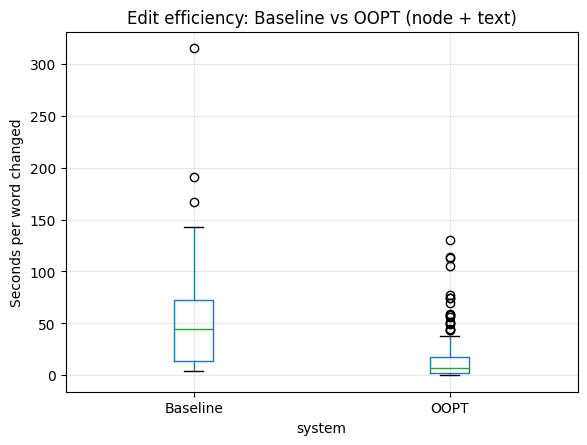

          count       mean        std  min        25%    50%     75%    max
system                                                                     
Baseline   47.0  59.134090  60.456341  4.5  13.693182  44.75  72.625  315.0
OOPT      211.0  14.476743  20.726129  0.0   2.547619   7.00  18.000  130.0

[Counts]
Baseline rows: 47
OOPT-node rows: 130
OOPT-text rows: 81
Final rows: 258


In [39]:
# -------------------------
# Boxplot
# -------------------------
plt.figure(figsize=(7,5))
final.boxplot(column="sec_per_word", by="system")
plt.suptitle("")
plt.ylabel("Seconds per word changed")
plt.title("Edit efficiency: Baseline vs OOPT (node + text)")
plt.grid(alpha=0.3)
plt.show()

# -------------------------
# 통계값 비교
# -------------------------
stats = final.groupby("system")["sec_per_word"].describe()
print(stats)

print("\n[Counts]")
print(f"Baseline rows: {len(baseline_all)}")
print(f"OOPT-node rows: {len(oopt_node_all)}")
print(f"OOPT-text rows: {len(oopt_text_all)}")
print(f"Final rows: {len(final)}")


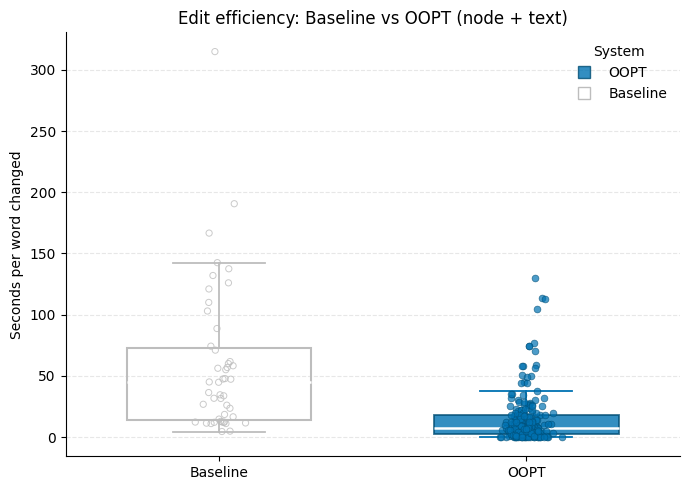

          count       mean        std  min        25%    50%     75%    max
system                                                                     
Baseline   47.0  59.134090  60.456341  4.5  13.693182  44.75  72.625  315.0
OOPT      211.0  14.476743  20.726129  0.0   2.547619   7.00  18.000  130.0

[Counts]
Baseline rows: 47
OOPT-node rows: 130
OOPT-text rows: 81
Final rows: 258

ENHANCED STATISTICS

Baseline:
  Count: 47
  Mean: 59.1341
  Median: 44.7500
  Std: 60.4563
  Min: 4.5000
  Max: 315.0000
  Q1: 13.6932
  Q3: 72.6250
  IQR: 58.9318

OOPT:
  Count: 211
  Mean: 14.4767
  Median: 7.0000
  Std: 20.7261
  Min: 0.0000
  Max: 130.0000
  Q1: 2.5476
  Q3: 18.0000
  IQR: 15.4524


In [40]:
# -------------------------
# Styled Boxplot (맞춤형)
# -------------------------
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

# 팔레트 (기존과 동일)
COLOR = {"Baseline": "#BDBDBD",  # 회색
         "OOPT": "#0072B2"}      # 파랑

def create_styled_boxplot(df, column, by_column, title="", ylabel="", figsize=(7,5)):
    """스타일 맞춤형 boxplot"""
    fig, ax = plt.subplots(figsize=figsize)
    
    # 시스템별 데이터 분리
    systems = df[by_column].unique()
    data_by_system = []
    positions = []
    colors = []
    
    for i, system in enumerate(systems):
        data = df[df[by_column] == system][column].dropna()
        if len(data) > 0:
            data_by_system.append(data)
            positions.append(i)
            colors.append(COLOR.get(system, "#666666"))
    
    if not data_by_system:
        print("No data to plot")
        return fig, ax
    
    # Boxplot 생성
    bp = ax.boxplot(data_by_system, positions=positions, widths=0.6, 
                    patch_artist=True, showfliers=False,
                    medianprops=dict(color='white', linewidth=1.8),
                    boxprops=dict(linewidth=1.3),
                    whiskerprops=dict(linewidth=1.3),
                    capprops=dict(linewidth=1.3),
                    # flierprops=dict(marker='o', markerfacecolor='red', 
                    #                markersize=4, alpha=0.6)
                    )
    
    # 박스 스타일링
    for patch, system in zip(bp['boxes'], systems):
        if system == "Baseline":
            patch.set_facecolor('none')
            patch.set_edgecolor(COLOR["Baseline"])
            patch.set_linewidth(1.5)
        else:  # OOPT
            patch.set_facecolor(COLOR["OOPT"])
            patch.set_edgecolor("#004D73")
            patch.set_alpha(0.8)
    
    # whisker, cap 색상 설정
    for i, system in enumerate(systems):
        color = COLOR.get(system, "#666666")
        # 각 박스당 2개의 whisker와 2개의 cap
        bp['whiskers'][i*2].set_color(color)
        bp['whiskers'][i*2+1].set_color(color)
        bp['caps'][i*2].set_color(color)
        bp['caps'][i*2+1].set_color(color)
    
    # 개별 점 추가 (jitter)
    for i, system in enumerate(systems):
        data = df[df[by_column] == system][column].dropna()
        if len(data) > 0:
            # jitter 추가
            jitter = np.random.default_rng(42).normal(0, 0.04, size=len(data))
            x_pos = np.full(len(data), i) + jitter
            
            if system == "Baseline":
                ax.scatter(x_pos, data, s=20, facecolors="none",
                          edgecolors=COLOR["Baseline"], linewidths=0.7, 
                          alpha=0.8, zorder=3)
            else:  # OOPT
                ax.scatter(x_pos, data, s=24, color=COLOR["OOPT"],
                          edgecolors="#004D73", linewidths=0.5, 
                          alpha=0.7, zorder=4)
    
    # 축 및 스타일 설정
    ax.set_xticks(range(len(systems)))
    ax.set_xticklabels(systems)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(axis="y", linestyle="--", alpha=0.3)
    
    # 스파인 제거
    for spine in ("top", "right"):
        ax.spines[spine].set_visible(False)
    
    # 범례 추가
    handles = [
        Line2D([0],[0], marker="s", mfc=COLOR["OOPT"], mec="#004D73", 
               color="none", markersize=8, alpha=0.8, label="OOPT"),
        Line2D([0],[0], marker="s", mfc="none", mec=COLOR["Baseline"], 
               color="none", markersize=8, label="Baseline"),
    ]
    ax.legend(handles=handles, frameon=False, title="System", loc="best")
    
    plt.tight_layout()
    return fig, ax

# -------------------------
# 기존 코드 대체
# -------------------------
fig, ax = create_styled_boxplot(
    final, 
    column="sec_per_word", 
    by_column="system",
    title="Edit efficiency: Baseline vs OOPT (node + text)",
    ylabel="Seconds per word changed",
    figsize=(7,5)
)

plt.show()

# -------------------------
# 통계값 비교 (기존과 동일)
# -------------------------
stats = final.groupby("system")["sec_per_word"].describe()
print(stats)

print("\n[Counts]")
print(f"Baseline rows: {len(baseline_all)}")
print(f"OOPT-node rows: {len(oopt_node_all)}")
print(f"OOPT-text rows: {len(oopt_text_all)}")
print(f"Final rows: {len(final)}")

# -------------------------
# 보너스: 향상된 통계 테이블
# -------------------------
print("\n" + "="*50)
print("ENHANCED STATISTICS")
print("="*50)

for system in final['system'].unique():
    data = final[final['system'] == system]['sec_per_word'].dropna()
    if len(data) > 0:
        print(f"\n{system}:")
        print(f"  Count: {len(data)}")
        print(f"  Mean: {data.mean():.4f}")
        print(f"  Median: {data.median():.4f}")
        print(f"  Std: {data.std():.4f}")
        print(f"  Min: {data.min():.4f}")
        print(f"  Max: {data.max():.4f}")
        print(f"  Q1: {data.quantile(0.25):.4f}")
        print(f"  Q3: {data.quantile(0.75):.4f}")
        print(f"  IQR: {data.quantile(0.75) - data.quantile(0.25):.4f}")

# -------------------------
# 대안: seaborn 스타일 (선택사항)
# -------------------------
# import seaborn as sns
# 
# plt.figure(figsize=(7,5))
# ax = sns.boxplot(data=final, x="system", y="sec_per_word", 
#                  palette={"Baseline": COLOR["Baseline"], "OOPT": COLOR["OOPT"]})
# 
# # 개별 점 추가
# sns.stripplot(data=final, x="system", y="sec_per_word", 
#               size=4, alpha=0.6, jitter=True, ax=ax)
# 
# ax.set_ylabel("Seconds per word changed")
# ax.set_title("Edit efficiency: Baseline vs OOPT (node + text)")
# ax.grid(axis="y", linestyle="--", alpha=0.3)
# plt.tight_layout()
# plt.show()

In [41]:
import pandas as pd, ast, matplotlib.pyplot as plt
import json, re
from pathlib import Path
from difflib import ndiff
# 추가할 import
from scipy import stats
import numpy as np

# ... (기존 코드 유지) ...

# -------------------------
# LaTeX 테이블 생성 함수
# -------------------------

def get_significance_symbol(p_value):
    """p-value에 따른 유의성 기호 반환"""
    if p_value < 0.001:
        return "***"
    elif p_value < 0.01:
        return "**"
    elif p_value < 0.05:
        return "*"
    else:
        return "-"

def generate_latex_table(final_df, metric_name="sec_per_word", table_caption="Edit efficiency comparison", table_label="tab:efficiency"):
    """통계 결과를 LaTeX 테이블 형태로 생성"""
    
    # 데이터 분리
    baseline_data = final_df[final_df["system"] == "Baseline"][metric_name].dropna()
    oopt_data = final_df[final_df["system"] == "OOPT"][metric_name].dropna()
    
    if len(baseline_data) == 0 or len(oopt_data) == 0:
        print("Warning: Insufficient data for comparison")
        return
    
    # 기술통계 계산
    baseline_mean = baseline_data.mean()
    baseline_std = baseline_data.std()
    oopt_mean = oopt_data.mean()
    oopt_std = oopt_data.std()
    
    # 통계적 검정
    # 정규성 검정
    baseline_normal = stats.shapiro(baseline_data).pvalue > 0.05 if len(baseline_data) >= 3 else False
    oopt_normal = stats.shapiro(oopt_data).pvalue > 0.05 if len(oopt_data) >= 3 else False
    
    # 적절한 검정 선택
    if baseline_normal and oopt_normal:
        # 정규분포: t-test
        _, p_value = stats.ttest_ind(baseline_data, oopt_data, equal_var=False)
        test_used = "t-test"
    else:
        # 비정규분포: Mann-Whitney U
        _, p_value = stats.mannwhitneyu(baseline_data, oopt_data, alternative='two-sided')
        test_used = "Mann-Whitney U"
    
    # 유의성 기호
    sig_symbol = get_significance_symbol(p_value)
    
    # LaTeX 테이블 생성
    latex_code = f"""\\begin{{table}}[t]
\\centering
\\small
\\setlength{{\\tabcolsep}}{{6pt}}
\\begin{{tabular}}{{lcccccc}}
\\toprule
& \\multicolumn{{2}}{{c}}{{Baseline}} & \\multicolumn{{2}}{{c}}{{OOPT}} & \\multicolumn{{2}}{{c}}{{Statistics}} \\\\
Metric & mean & std & mean & std & p & Sig. \\\\
\\midrule
{metric_name.replace('_', ' ').title()} & {baseline_mean:.2f} & {baseline_std:.2f} & {oopt_mean:.2f} & {oopt_std:.2f} & {p_value:.3f} & {sig_symbol} \\\\
\\bottomrule
\\end{{tabular}}
\\caption{{{table_caption}}}
\\label{{{table_label}}}
\\end{{table}}

% Note: Sig.: * p < .05, ** p < .01, *** p < .001; '-' n.s.
% Test used: {test_used}
% Sample sizes: Baseline n={len(baseline_data)}, OOPT n={len(oopt_data)}"""
    
    return latex_code

def generate_comprehensive_latex_table(final_df, metrics_info, table_caption="Performance comparison", table_label="tab:performance"):
    """여러 메트릭을 포함한 종합 LaTeX 테이블 생성"""
    
    latex_rows = []
    
    for metric_name, display_name in metrics_info.items():
        # 데이터 분리
        baseline_data = final_df[final_df["system"] == "Baseline"][metric_name].dropna()
        oopt_data = final_df[final_df["system"] == "OOPT"][metric_name].dropna()
        
        if len(baseline_data) == 0 or len(oopt_data) == 0:
            continue
        
        # 기술통계
        baseline_mean = baseline_data.mean()
        baseline_std = baseline_data.std()
        oopt_mean = oopt_data.mean()
        oopt_std = oopt_data.std()
        
        # 통계적 검정
        try:
            baseline_normal = stats.shapiro(baseline_data).pvalue > 0.05 if len(baseline_data) >= 3 else False
            oopt_normal = stats.shapiro(oopt_data).pvalue > 0.05 if len(oopt_data) >= 3 else False
            
            if baseline_normal and oopt_normal:
                _, p_value = stats.ttest_ind(baseline_data, oopt_data, equal_var=False)
            else:
                _, p_value = stats.mannwhitneyu(baseline_data, oopt_data, alternative='two-sided')
        except:
            p_value = 1.0  # 검정 실패시 유의하지 않음으로 처리
        
        # 유의성 기호
        sig_symbol = get_significance_symbol(p_value)
        
        # 행 생성
        latex_rows.append(f"{display_name} & {baseline_mean:.2f} & {baseline_std:.2f} & {oopt_mean:.2f} & {oopt_std:.2f} & {p_value:.6f} & {sig_symbol} \\\\")
    
    # 전체 테이블 조합
    latex_code = f"""\\begin{{table}}[t]
\\centering
\\small
\\setlength{{\\tabcolsep}}{{6pt}}
\\begin{{tabular}}{{lcccccc}}
\\toprule
& \\multicolumn{{2}}{{c}}{{Baseline}} & \\multicolumn{{2}}{{c}}{{OOPT}} & \\multicolumn{{2}}{{c}}{{Statistics}} \\\\
Metric & mean & std & mean & std & p & Sig. \\\\
\\midrule
{chr(10).join(latex_rows)}
\\bottomrule
\\end{{tabular}}
\\caption{{{table_caption}}}
\\label{{{table_label}}}
\\end{{table}}

% Note: Sig.: * p < .05, ** p < .01, *** p < .001; '-' n.s."""
    
    return latex_code

# -------------------------
# 실제 사용 예시
# -------------------------

# 단일 메트릭 테이블
print("="*60)
print("LaTeX TABLE - SINGLE METRIC")
print("="*60)

latex_table = generate_latex_table(
    final, 
    metric_name="sec_per_word",
    table_caption="Edit efficiency: OOPT vs Baseline (seconds per word changed)",
    table_label="tab:edit_efficiency"
)

if latex_table:
    print(latex_table)

# 다중 메트릭 테이블 (만약 다른 메트릭들이 있다면)
print("\n" + "="*60)
print("LaTeX TABLE - MULTIPLE METRICS")
print("="*60)

# 현재 데이터에서 사용 가능한 메트릭들
available_metrics = {
    "sec_per_word": "Seconds per Word",
    "duration_sec": "Duration (sec)",
    "words_changed": "Words Changed"
}

# 다중 메트릭이 있는 경우의 테이블
multi_latex_table = generate_comprehensive_latex_table(
    final,
    available_metrics,
    table_caption="Performance metrics: OOPT vs Baseline",
    table_label="tab:performance_summary"
)

print(multi_latex_table)

# -------------------------
# 추가: 통계 요약 정보도 함께 출력
# -------------------------
print("\n" + "="*60)
print("STATISTICAL SUMMARY FOR LATEX")
print("="*60)

baseline_data = final[final["system"] == "Baseline"]["sec_per_word"].dropna()
oopt_data = final[final["system"] == "OOPT"]["sec_per_word"].dropna()

if len(baseline_data) > 0 and len(oopt_data) > 0:
    print(f"Sample sizes: Baseline n={len(baseline_data)}, OOPT n={len(oopt_data)}")
    print(f"Baseline: M={baseline_data.mean():.3f}, SD={baseline_data.std():.3f}")
    print(f"OOPT: M={oopt_data.mean():.3f}, SD={oopt_data.std():.3f}")
    
    # 정규성 확인
    baseline_normal = stats.shapiro(baseline_data).pvalue > 0.05 if len(baseline_data) >= 3 else False
    oopt_normal = stats.shapiro(oopt_data).pvalue > 0.05 if len(oopt_data) >= 3 else False
    
    if baseline_normal and oopt_normal:
        _, p_val = stats.ttest_ind(baseline_data, oopt_data, equal_var=False)
        test_name = "Welch's t-test"
    else:
        _, p_val = stats.mannwhitneyu(baseline_data, oopt_data, alternative='two-sided')
        test_name = "Mann-Whitney U test"
    
    print(f"Statistical test: {test_name}")
    print(f"p-value: {p_val:.8}")
    print(f"Significance: {get_significance_symbol(p_val)}")

LaTeX TABLE - SINGLE METRIC
\begin{table}[t]
\centering
\small
\setlength{\tabcolsep}{6pt}
\begin{tabular}{lcccccc}
\toprule
& \multicolumn{2}{c}{Baseline} & \multicolumn{2}{c}{OOPT} & \multicolumn{2}{c}{Statistics} \\
Metric & mean & std & mean & std & p & Sig. \\
\midrule
Sec Per Word & 59.13 & 60.46 & 14.48 & 20.73 & 0.000 & *** \\
\bottomrule
\end{tabular}
\caption{Edit efficiency: OOPT vs Baseline (seconds per word changed)}
\label{tab:edit_efficiency}
\end{table}

% Note: Sig.: * p < .05, ** p < .01, *** p < .001; '-' n.s.
% Test used: Mann-Whitney U
% Sample sizes: Baseline n=47, OOPT n=211

LaTeX TABLE - MULTIPLE METRICS
\begin{table}[t]
\centering
\small
\setlength{\tabcolsep}{6pt}
\begin{tabular}{lcccccc}
\toprule
& \multicolumn{2}{c}{Baseline} & \multicolumn{2}{c}{OOPT} & \multicolumn{2}{c}{Statistics} \\
Metric & mean & std & mean & std & p & Sig. \\
\midrule
Seconds per Word & 59.13 & 60.46 & 14.48 & 20.73 & 0.000000 & *** \\
Duration (sec) & 196.00 & 171.21 & 19.52 & 23.5

KeyError: 'OOPT'

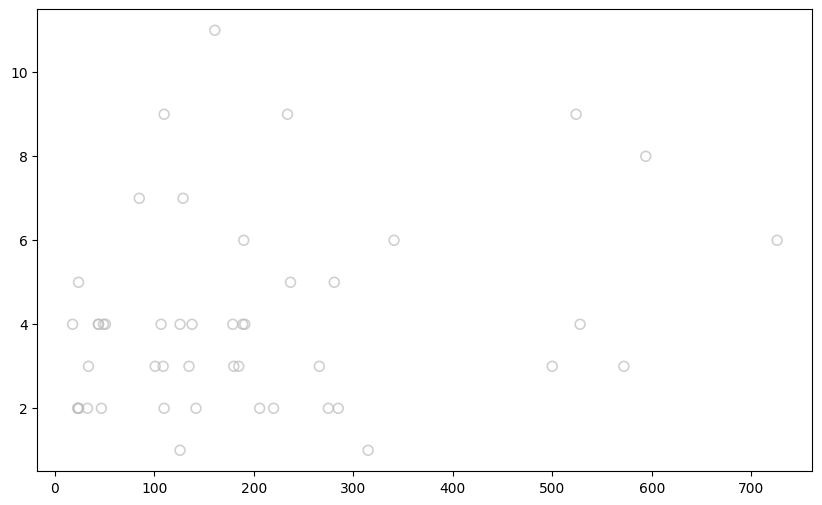

In [49]:
# -------------------------
# Time vs Word Count Scatter Plot
# -------------------------
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

# 팔레트 (기존과 동일)
COLOR = {"Baseline": "#BDBDBD",  # 회색
         "PromptBlock": "#0072B2"}      # 파랑

def create_time_word_scatter(df, title="", figsize=(10, 6)):
    """시간 vs 단어 수정 개수 scatter plot"""
    fig, ax = plt.subplots(figsize=figsize)
    
    # 시스템별로 데이터 플롯
    for system in df['system'].unique():
        system_data = df[df['system'] == system]
        
        if system == "Baseline":
            ax.scatter(system_data['duration_sec'], 
                      system_data['words_changed'],
                      s=50, 
                      facecolors="none",
                      edgecolors=COLOR["Baseline"], 
                      linewidths=1.2,
                      alpha=0.7,
                      label=system,
                      zorder=3)
        else:  # OOPT
            ax.scatter(system_data['duration_sec'], 
                      system_data['words_changed'],
                      s=60, 
                      color=COLOR["OOPT"],
                      edgecolors="#004D73", 
                      linewidths=0.8,
                      alpha=0.7,
                      label=system,
                      zorder=4)
    
    # 효율성 참조선 추가 (같은 기울기 = 같은 효율성)
    max_time = df['duration_sec'].max()
    max_words = df['words_changed'].max()
    
    # 여러 효율성 레벨의 참조선
    efficiency_levels = [0.1, 0.2, 0.5, 1.0, 2.0]  # words per second
    
    for eff in efficiency_levels:
        line_end_time = min(max_time, max_words / eff)
        line_end_words = eff * line_end_time
        
        ax.plot([0, line_end_time], [0, line_end_words], 
                '--', color='gray', alpha=0.3, linewidth=0.8)
        
        # 레이블 위치 계산
        label_time = line_end_time * 0.8
        label_words = eff * label_time
        
        if label_words <= max_words * 0.9:  # 범위 내에서만 레이블 표시
            ax.text(label_time, label_words, f'{eff:.1f} w/s', 
                   rotation=np.degrees(np.arctan(eff)), 
                   fontsize=8, alpha=0.6, ha='center',
                   bbox=dict(boxstyle="round,pad=0.2", facecolor="white", alpha=0.8))
    
    # 축 및 스타일 설정
    ax.set_xlabel("Duration (seconds)")
    ax.set_ylabel("Words Changed")
    ax.set_title(title)
    ax.grid(True, linestyle="--", alpha=0.3)
    
    # 스파인 제거
    for spine in ("top", "right"):
        ax.spines[spine].set_visible(False)
    
    # 범례 추가
    ax.legend(frameon=False, title="System", loc="upper left")
    
    # 0,0에서 시작하도록 축 설정
    ax.set_xlim(left=0)
    ax.set_ylim(bottom=0)
    
    plt.tight_layout()
    return fig, ax

# -------------------------
# 효율성 분석을 위한 추가 함수
# -------------------------
def analyze_efficiency(df):
    """효율성 분석 (words per second)"""
    print("="*60)
    print("EFFICIENCY ANALYSIS (Words per Second)")
    print("="*60)
    
    for system in df['system'].unique():
        system_data = df[df['system'] == system]
        efficiency = system_data['words_changed'] / system_data['duration_sec']
        
        print(f"\n{system}:")
        print(f"  Count: {len(system_data)}")
        print(f"  Mean efficiency: {efficiency.mean():.4f} words/sec")
        print(f"  Median efficiency: {efficiency.median():.4f} words/sec")
        print(f"  Std efficiency: {efficiency.std():.4f} words/sec")
        print(f"  Min efficiency: {efficiency.min():.4f} words/sec")
        print(f"  Max efficiency: {efficiency.max():.4f} words/sec")
    
    # 효율성 비교
    baseline_eff = df[df['system'] == 'Baseline']['words_changed'] / df[df['system'] == 'Baseline']['duration_sec']
    oopt_eff = df[df['system'] == 'OOPT']['words_changed'] / df[df['system'] == 'OOPT']['duration_sec']
    
    improvement = (oopt_eff.mean() - baseline_eff.mean()) / baseline_eff.mean() * 100
    print(f"\nOverall improvement: {improvement:.1f}%")
    
    return efficiency

# -------------------------
# 기존 코드 대체
# -------------------------
# final 데이터프레임이 있다고 가정하고 플롯 생성
fig, ax = create_time_word_scatter(
    final, 
    title="Edit Efficiency: Time vs Words Changed (Baseline vs OOPT)",
    figsize=(10, 6)
)

plt.show()

# -------------------------
# 효율성 분석
# -------------------------
efficiency_stats = analyze_efficiency(final)

# -------------------------
# 보너스: 구간별 효율성 분석
# -------------------------
print("\n" + "="*60)
print("EFFICIENCY BY TIME RANGES")
print("="*60)

time_ranges = [(0, 30), (30, 60), (60, 120), (120, float('inf'))]
range_labels = ["0-30s", "30-60s", "60-120s", "120s+"]

for (start, end), label in zip(time_ranges, range_labels):
    range_data = final[(final['duration_sec'] >= start) & (final['duration_sec'] < end)]
    if len(range_data) > 0:
        print(f"\n{label}:")
        for system in range_data['system'].unique():
            system_range = range_data[range_data['system'] == system]
            if len(system_range) > 0:
                efficiency = system_range['words_changed'] / system_range['duration_sec']
                print(f"  {system}: {efficiency.mean():.4f} w/s (n={len(system_range)})")

# -------------------------
# 대안: 더 세밀한 시각화 (선택사항)
# -------------------------
# 효율성 히트맵이나 density plot을 원한다면 아래 코드 사용 가능
# import seaborn as sns
# 
# plt.figure(figsize=(12, 8))
# 
# # 서브플롯으로 시스템별 분리
# fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6), sharey=True)
# 
# for i, system in enumerate(['Baseline', 'OOPT']):
#     ax = ax1 if i == 0 else ax2
#     system_data = final[final['system'] == system]
#     
#     ax.scatter(system_data['duration_sec'], system_data['words_changed'],
#               s=60, alpha=0.6, color=COLOR[system])
#     ax.set_title(f'{system} System')
#     ax.set_xlabel('Duration (seconds)')
#     if i == 0:
#         ax.set_ylabel('Words Changed')
#     ax.grid(True, alpha=0.3)
# 
# plt.tight_layout()
# plt.show()

KeyError: 'OOPT'

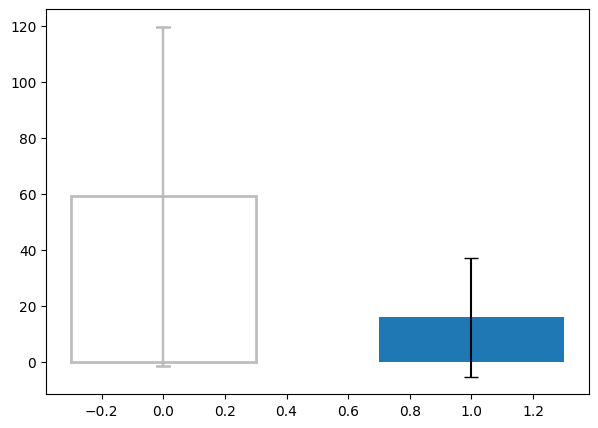

In [50]:
# -------------------------
# Styled Bar Chart (맞춤형)
# -------------------------
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

# 팔레트 (기존과 동일)
COLOR = {"Baseline": "#BDBDBD",  # 회색
         "PromptBlock": "#0072B2"}      # 파랑

def create_styled_barchart(df, column, by_column, title="", ylabel="", figsize=(7,5)):
    """스타일 맞춤형 bar chart"""
    fig, ax = plt.subplots(figsize=figsize)
    
    # 시스템별 통계 계산
    systems = df[by_column].unique()
    means = []
    stds = []
    colors = []
    counts = []
    
    for system in systems:
        data = df[df[by_column] == system][column].dropna()
        if len(data) > 0:
            means.append(data.mean())
            stds.append(data.std())
            colors.append(COLOR.get(system, "#666666"))
            counts.append(len(data))
        else:
            means.append(0)
            stds.append(0)
            colors.append(COLOR.get(system, "#666666"))
            counts.append(0)
    
    if not means:
        print("No data to plot")
        return fig, ax
    
    # x 위치
    x_pos = np.arange(len(systems))
    
    # 바 차트 생성
    bars = ax.bar(x_pos, means, yerr=stds, width=0.6, 
                  capsize=5, error_kw={'linewidth': 1.5})
    
    # 바 스타일링
    for i, (bar, system) in enumerate(zip(bars, systems)):
        if system == "Baseline":
            bar.set_facecolor('none')
            bar.set_edgecolor(COLOR["Baseline"])
            bar.set_linewidth(2)
            # 에러바 색상
            ax.errorbar(i, means[i], yerr=stds[i], fmt='none', 
                       ecolor=COLOR["Baseline"], capsize=5, 
                       linewidth=1.5, zorder=10)
        else:  # OOPT
            bar.set_facecolor(COLOR["OOPT"])
            bar.set_edgecolor("#004D73")
            bar.set_alpha(0.8)
            bar.set_linewidth(1)
            # 에러바 색상
            ax.errorbar(i, means[i], yerr=stds[i], fmt='none', 
                       ecolor="#004D73", capsize=5, 
                       linewidth=1.5, zorder=10)
    
    # 바 위에 통계값 표시 (선택사항)
    for i, (mean, count) in enumerate(zip(means, counts)):
        ax.text(i, mean + stds[i] + max(means) * 0.02, 
                f'n={count}', ha='center', va='bottom', 
                fontsize=9, alpha=0.8)
    
    # 축 및 스타일 설정
    ax.set_xticks(x_pos)
    ax.set_xticklabels(systems)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(axis="y", linestyle="--", alpha=0.3)
    
    # y축 범위 조정 (여백 추가)
    max_val = max([m + s for m, s in zip(means, stds)])
    ax.set_ylim(0, max_val * 1.15)
    
    # 스파인 제거
    for spine in ("top", "right"):
        ax.spines[spine].set_visible(False)
    
    # 범례 추가
    handles = [
        Line2D([0],[0], marker="s", mfc=COLOR["OOPT"], mec="#004D73", 
               color="none", markersize=8, alpha=0.8, label="OOPT"),
        Line2D([0],[0], marker="s", mfc="none", mec=COLOR["Baseline"], 
               color="none", markersize=8, label="Baseline"),
    ]
    ax.legend(handles=handles, frameon=False, title="System", loc="best")
    
    plt.tight_layout()
    return fig, ax

# -------------------------
# 기존 코드 대체
# -------------------------
fig, ax = create_styled_barchart(
    final, 
    column="sec_per_word", 
    by_column="system",
    title="Edit efficiency: Baseline vs OOPT (node + text)",
    ylabel="Seconds per word changed",
    figsize=(7,5)
)

plt.show()

# -------------------------
# 통계값 비교 (기존과 동일)
# -------------------------
stats = final.groupby("system")["sec_per_word"].describe()
print(stats)

print("\n[Counts]")
print(f"Baseline rows: {len(baseline_all)}")
print(f"OOPT-node rows: {len(oopt_node_all)}")
print(f"OOPT-text rows: {len(oopt_text_all)}")
print(f"Final rows: {len(final)}")

# -------------------------
# 보너스: 향상된 통계 테이블
# -------------------------
print("\n" + "="*50)
print("ENHANCED STATISTICS")
print("="*50)

for system in final['system'].unique():
    data = final[final['system'] == system]['sec_per_word'].dropna()
    if len(data) > 0:
        print(f"\n{system}:")
        print(f"  Count: {len(data)}")
        print(f"  Mean: {data.mean():.4f}")
        print(f"  Median: {data.median():.4f}")
        print(f"  Std: {data.std():.4f}")
        print(f"  Min: {data.min():.4f}")
        print(f"  Max: {data.max():.4f}")
        print(f"  Q1: {data.quantile(0.25):.4f}")
        print(f"  Q3: {data.quantile(0.75):.4f}")
        print(f"  IQR: {data.quantile(0.75) - data.quantile(0.25):.4f}")

# -------------------------
# 대안: 다양한 바 차트 스타일 (선택사항)
# -------------------------

# 1. 중앙값 기반 바 차트
def create_median_barchart(df, column, by_column, title="", ylabel="", figsize=(7,5)):
    """중앙값 기반 바 차트"""
    fig, ax = plt.subplots(figsize=figsize)
    
    systems = df[by_column].unique()
    medians = []
    q1s = []
    q3s = []
    colors = []
    
    for system in systems:
        data = df[df[by_column] == system][column].dropna()
        if len(data) > 0:
            medians.append(data.median())
            q1s.append(data.quantile(0.25))
            q3s.append(data.quantile(0.75))
            colors.append(COLOR.get(system, "#666666"))
        else:
            medians.append(0)
            q1s.append(0)
            q3s.append(0)
            colors.append(COLOR.get(system, "#666666"))
    
    x_pos = np.arange(len(systems))
    
    # IQR을 에러바로 사용
    yerr_low = [med - q1 for med, q1 in zip(medians, q1s)]
    yerr_high = [q3 - med for med, q3 in zip(medians, q3s)]
    
    bars = ax.bar(x_pos, medians, width=0.6)
    
    # 바 스타일링
    for i, (bar, system) in enumerate(zip(bars, systems)):
        if system == "Baseline":
            bar.set_facecolor('none')
            bar.set_edgecolor(COLOR["Baseline"])
            bar.set_linewidth(2)
        else:  # OOPT
            bar.set_facecolor(COLOR["OOPT"])
            bar.set_edgecolor("#004D73")
            bar.set_alpha(0.8)
    
    # IQR 에러바
    ax.errorbar(x_pos, medians, yerr=[yerr_low, yerr_high], 
                fmt='none', ecolor='black', capsize=5, capthick=1.5, 
                linewidth=1.5, alpha=0.7)
    
    ax.set_xticks(x_pos)
    ax.set_xticklabels(systems)
    ax.set_ylabel(ylabel + " (Median ± IQR)")
    ax.set_title(title)
    ax.grid(axis="y", linestyle="--", alpha=0.3)
    
    for spine in ("top", "right"):
        ax.spines[spine].set_visible(False)
    
    plt.tight_layout()
    return fig, ax

# 2. 수평 바 차트
def create_horizontal_barchart(df, column, by_column, title="", ylabel="", figsize=(7,5)):
    """수평 바 차트"""
    fig, ax = plt.subplots(figsize=figsize)
    
    systems = df[by_column].unique()
    means = []
    stds = []
    
    for system in systems:
        data = df[df[by_column] == system][column].dropna()
        if len(data) > 0:
            means.append(data.mean())
            stds.append(data.std())
        else:
            means.append(0)
            stds.append(0)
    
    y_pos = np.arange(len(systems))
    
    bars = ax.barh(y_pos, means, xerr=stds, height=0.6, 
                   capsize=5,  error_kw={'linewidth': 1.5})
    
    # 바 스타일링
    for i, (bar, system) in enumerate(zip(bars, systems)):
        if system == "Baseline":
            bar.set_facecolor('none')
            bar.set_edgecolor(COLOR["Baseline"])
            bar.set_linewidth(2)
        else:  # OOPT
            bar.set_facecolor(COLOR["OOPT"])
            bar.set_edgecolor("#004D73")
            bar.set_alpha(0.8)
    
    ax.set_yticks(y_pos)
    ax.set_yticklabels(systems)
    ax.set_xlabel(ylabel)
    ax.set_title(title)
    ax.grid(axis="x", linestyle="--", alpha=0.3)
    
    for spine in ("top", "right"):
        ax.spines[spine].set_visible(False)
    
    plt.tight_layout()
    return fig, ax

# 예시 사용법 (주석 해제하여 사용):
# fig2, ax2 = create_median_barchart(final, "sec_per_word", "system",
#                                   title="Edit efficiency (Median): Baseline vs OOPT",
#                                   ylabel="Seconds per word changed")
# plt.show()

# fig3, ax3 = create_horizontal_barchart(final, "sec_per_word", "system",
#                                        title="Edit efficiency: Baseline vs OOPT",
#                                        ylabel="Seconds per word changed")
# plt.show()

             count      mean       std       min       25%       50%  \
system                                                                 
Baseline      47.0  0.043641  0.046847  0.003175  0.013776  0.022346   
PromptBlock  190.0  0.335101  0.783227  0.007692  0.051389  0.111111   

                  75%       max  
system                           
Baseline     0.073377  0.222222  
PromptBlock  0.250000  8.000000  

[Counts]
Final rows (after removing zeros): 237

ENHANCED STATISTICS - WORDS PER SECOND

Baseline:
  Count: 47
  Mean: 0.0436
  Median: 0.0223
  Std: 0.0468
  Min: 0.0032
  Max: 0.2222
  Q1: 0.0138
  Q3: 0.0734
  IQR: 0.0596

PromptBlock:
  Count: 190
  Mean: 0.3351
  Median: 0.1111
  Std: 0.7832
  Min: 0.0077
  Max: 8.0000
  Q1: 0.0514
  Q3: 0.2500
  IQR: 0.1986


/var/folders/yy/wmmdvn295kn5535yf3g57f2m0000gn/T/ipykernel_19108/3924590105.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  final['words_per_sec'] = 1 / final['sec_per_word']


KeyError: 'OOPT'

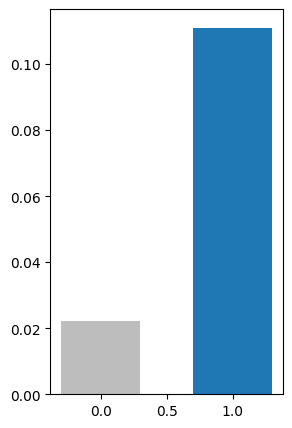

In [51]:
# -------------------------
# Styled Bar Chart (맞춤형) - Modified for words_per_sec
# -------------------------
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

# 팔레트 (기존과 동일)
COLOR = {"Baseline": "#BDBDBD",  # 회색
         "PromptBlock": "#0072B2"}      # 파랑

# -------------------------
# Data preprocessing: Convert sec_per_word to words_per_sec and remove zeros
# -------------------------
# Assuming 'final' dataframe exists with 'sec_per_word' column
# Convert sec_per_word to words_per_sec (reciprocal)
final['words_per_sec'] = 1 / final['sec_per_word']

# Remove rows where sec_per_word was 0 (which would make words_per_sec infinite)
# Also remove any infinite or NaN values
final = final[np.isfinite(final['words_per_sec']) & (final['words_per_sec'] > 0)]

# -------------------------
# 통계값 비교 - Updated for words_per_sec
# -------------------------
stats = final.groupby("system")["words_per_sec"].describe()
print(stats)

print("\n[Counts]")
print(f"Final rows (after removing zeros): {len(final)}")

# -------------------------
# 보너스: 향상된 통계 테이블 - Updated for words_per_sec
# -------------------------
print("\n" + "="*50)
print("ENHANCED STATISTICS - WORDS PER SECOND")
print("="*50)

for system in final['system'].unique():
    data = final[final['system'] == system]['words_per_sec'].dropna()
    if len(data) > 0:
        print(f"\n{system}:")
        print(f"  Count: {len(data)}")
        print(f"  Mean: {data.mean():.4f}")
        print(f"  Median: {data.median():.4f}")
        print(f"  Std: {data.std():.4f}")
        print(f"  Min: {data.min():.4f}")
        print(f"  Max: {data.max():.4f}")
        print(f"  Q1: {data.quantile(0.25):.4f}")
        print(f"  Q3: {data.quantile(0.75):.4f}")
        print(f"  IQR: {data.quantile(0.75) - data.quantile(0.25):.4f}")

# -------------------------
# 대안: 다양한 바 차트 스타일 (선택사항) - Updated for words_per_sec
# -------------------------

# 1. 중앙값 기반 바 차트
def create_median_barchart(df, column, by_column, title="", ylabel="", figsize=(3,5)):
    """중앙값 기반 바 차트"""
    fig, ax = plt.subplots(figsize=figsize)
    
    systems = df[by_column].unique()
    medians = []
    q1s = []
    q3s = []
    colors = []
    
    for system in systems:
        data = df[df[by_column] == system][column].dropna()
        if len(data) > 0:
            medians.append(data.median())
            q1s.append(data.quantile(0.25))
            q3s.append(data.quantile(0.75))
            colors.append(COLOR.get(system, "#666666"))
        else:
            medians.append(0)
            q1s.append(0)
            q3s.append(0)
            colors.append(COLOR.get(system, "#666666"))
    
    x_pos = np.arange(len(systems))
    
    # IQR을 에러바로 사용
    yerr_low = [med - q1 for med, q1 in zip(medians, q1s)]
    yerr_high = [q3 - med for med, q3 in zip(medians, q3s)]
    
    bars = ax.bar(x_pos, medians, width=0.6)
    
    # 바 스타일링
    for i, (bar, system) in enumerate(zip(bars, systems)):
        if system == "Baseline":
            bar.set_facecolor(COLOR["Baseline"])
            # bar.set_edgecolor(COLOR["Baseline"])
            bar.set_linewidth(2)
        else:  # OOPT
            bar.set_facecolor(COLOR["OOPT"])
            # bar.set_edgecolor("#004D73")
            bar.set_alpha(0.8)
    
    # IQR 에러바
    ax.errorbar(x_pos, medians, yerr=[yerr_low, yerr_high], 
                fmt='none', ecolor='black', capsize=5, 
                linewidth=1.5, alpha=0.7)
    
    ax.set_xticks(x_pos)
    ax.set_xticklabels(systems)
    ax.set_ylabel(ylabel + " (Median ± IQR)")
    ax.set_title(title)
    ax.grid(axis="y", linestyle="--", alpha=0.3)
    
    for spine in ("top", "right"):
        ax.spines[spine].set_visible(False)
    
    plt.tight_layout()
    return fig, ax

# 예시 사용법 (주석 해제하여 사용):
fig2, ax2 = create_median_barchart(final, "words_per_sec", "system",
                                  title="Number of words changed per second",
                                  ylabel="Words changed per second")
plt.savefig("figure_0903/words_per_sec_study1.pdf", dpi=300, bbox_inches="tight")
# fig3, ax3 = create_horizontal_barchart(final, "words_per_sec", "system",
#                                        title="Edit efficiency: Baseline vs OOPT",
#                                        ylabel="Words changed per second")
plt.show()

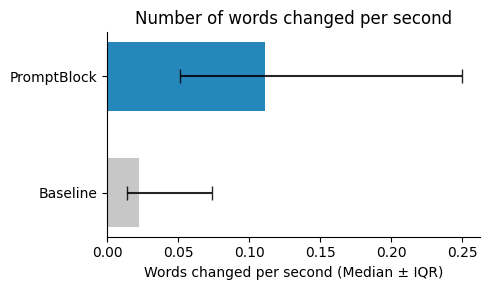

In [56]:
# 통일 팔레트 & 라벨
COLOR = {"baseline": "#BDBDBD", "system1": "#BDBDBD",
         "oopt": "#0072B2",    "system2": "#0072B2"}
LABEL = {"baseline": "Baseline", "system1": "Baseline",
         "oopt": "OOPT",        "system2": "OOPT"}

def _norm_key(s):
    return str(s).strip().lower()

def create_median_horizontal_barchart(df, column, by_column, title="", xlabel="", figsize=(5,3)):
    """중앙값 기반 horizontal bar 차트 (일관 스타일)"""
    fig, ax = plt.subplots(figsize=figsize)
    
    systems = df[by_column].unique()
    medians, q1s, q3s, colors, labels = [], [], [], [], []
    
    for system in systems:
        data = df[df[by_column] == system][column].dropna()
        if len(data) > 0:
            med = data.median()
            q1, q3 = data.quantile(0.25), data.quantile(0.75)
        else:
            med = q1 = q3 = 0.0

        key = _norm_key(system)
        medians.append(med)
        q1s.append(q1)
        q3s.append(q3)
        colors.append(COLOR.get(key, "#0072b2"))
        labels.append(LABEL.get(key, str(system)))

    y_pos = np.arange(len(systems))
    
    # IQR을 에러바로 사용 (x축 방향)
    xerr_low  = [med - q1 for med, q1 in zip(medians, q1s)]
    xerr_high = [q3 - med for med, q3 in zip(medians, q3s)]
    
    bars = ax.barh(y_pos, medians, height=0.6, color=colors, alpha=0.85, linewidth=1.2)
    
    ax.errorbar(medians, y_pos, xerr=[xerr_low, xerr_high],
                fmt='none', ecolor='black', capsize=5, linewidth=1.5, alpha=0.85)
    
    ax.set_yticks(y_pos)
    ax.set_yticklabels(labels)  # Baseline / OOPT로 통일
    ax.set_xlabel(xlabel + " (Median ± IQR)")
    ax.set_title(title)
    # ax.grid(axis="x", linestyle="--", alpha=0.3)
    
    for spine in ("top", "right"):
        ax.spines[spine].set_visible(False)
    
    plt.tight_layout()
    return fig, ax

# 예시
fig_h, ax_h = create_median_horizontal_barchart(
    final, "words_per_sec", "system",
    title="Number of words changed per second",
    xlabel="Words changed per second"
)
plt.savefig("figure_0903/words_per_sec_study1_horizontal.svg", dpi=300, bbox_inches="tight")
plt.show()


In [47]:
final["system"] = final["system"].replace({"Baseline": "Baseline", "OOPT": "PromptBlock"})

/var/folders/yy/wmmdvn295kn5535yf3g57f2m0000gn/T/ipykernel_19108/2229671701.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  final["system"] = final["system"].replace({"Baseline": "Baseline", "OOPT": "PromptBlock"})


KeyError: 'words_per_sec'

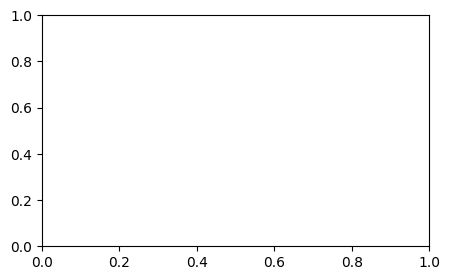

In [ ]:
def create_median_horizontal_barchart(df, column, by_column, title="", xlabel="", figsize=(5,3)):
    """중앙값 기반 horizontal bar 차트"""
    fig, ax = plt.subplots(figsize=figsize)
    
    systems = df[by_column].unique()
    medians = []
    q1s = []
    q3s = []
    colors = []
    
    for system in systems:
        data = df[df[by_column] == system][column].dropna()
        if len(data) > 0:
            medians.append(data.median())
            q1s.append(data.quantile(0.25))
            q3s.append(data.quantile(0.75))
            colors.append(COLOR.get(system, "#666666"))
        else:
            medians.append(0)
            q1s.append(0)
            q3s.append(0)
            colors.append(COLOR.get(system, "#666666"))
    
    y_pos = np.arange(len(systems))
    
    # IQR 에러바 길이
    xerr_low = [med - q1 for med, q1 in zip(medians, q1s)]
    xerr_high = [q3 - med for med, q3 in zip(medians, q3s)]
    
    bars = ax.barh(y_pos, medians, height=0.6, color=colors)
    
    # IQR 에러바 (x축 방향)
    ax.errorbar(medians, y_pos, 
                xerr=[xerr_low, xerr_high], fmt='none',
                ecolor='black', capsize=5, linewidth=1.5, alpha=0.7)
    
    ax.set_yticks(y_pos)
    ax.set_yticklabels(systems)
    ax.set_xlabel(xlabel + " (Median ± IQR)")
    ax.set_title(title)
    # ax.grid(axis="x", linestyle="--", alpha=0.3)
    
    for spine in ("top", "right"):
        ax.spines[spine].set_visible(False)
    
    plt.tight_layout()
    return fig, ax
fig_h, ax_h = create_median_horizontal_barchart(
    final, "words_per_sec", "system",
    title="Number of words changed per second",
    xlabel="Words changed per second"
)
plt.savefig("figure_0903/words_per_sec_study1_horizontal.svg", dpi=300, bbox_inches="tight")
plt.show()


In [ ]:
# =========================
# Paired t-test (Baseline vs OOPT) for words_per_sec
# =========================
import numpy as np
import pandas as pd
import pingouin as pg

# 1) 참가자 × 시스템별 평균(또는 중앙값으로 바꾸고 싶으면 .median())
eff = (final
       .groupby(['pid', 'system'])['words_per_sec']
       .mean()
       .reset_index())

# 2) 참가자 기준으로 Baseline/OOPT를 같은 행에 정렬
wide = eff.pivot(index='pid', columns='system', values='words_per_sec').dropna(subset=['Baseline','OOPT'])

# 3) 대응표본 t-test
res = pg.ttest(wide['Baseline'], wide['OOPT'], paired=True, alternative='two-sided')
print("\nPaired t-test (Baseline vs OOPT)")
print(res)

# 4) 기술통계 같이 출력(표용)
desc = wide[['Baseline','OOPT']].agg(['count','mean','std','median','min','max']).T
print("\nDescriptives (participant-level means)")
print(desc)

# 5) (선택) 정규성 체크: 차이분포( OOPT - Baseline )
diff = wide['OOPT'] - wide['Baseline']
print("\nNormality of paired differences (Shapiro):")
print(pg.normality(diff.to_frame(name='diff')))

# 6) (선택) 비모수 대안: Wilcoxon signed-rank
wil = pg.wilcoxon(wide['Baseline'], wide['OOPT'], alternative='two-sided')
print("\nWilcoxon signed-rank test")
print(wil)

# 7) 논문용 요약 문장 자동 포맷
t  = res.at[0, 'T']
df = int(res.at[0, 'dof'])
p  = res.at[0, 'p-val']
d  = res.at[0, 'cohen-d']   # paired면 dz로 해석
ci = res.at[0, 'CI95%']     # 예: [low, high]

m_b, sd_b = wide['Baseline'].mean(), wide['Baseline'].std()
m_o, sd_o = wide['OOPT'].mean(), wide['OOPT'].std()

print(
    f"\nReport:\n"
    f"Editing efficiency (words/s) was higher/lower with OOPT (M={m_o:.3f}, SD={sd_o:.3f}) "
    f"than with Baseline (M={m_b:.3f}, SD={sd_b:.3f}); "
    f"t({df}) = {t:.2f}, p = {p:.3f}, dz = {d:.2f}, 95% CI = {ci}."
)



Paired t-test (Baseline vs OOPT)
              T  dof alternative     p-val           CI95%   cohen-d   BF10  \
T-test -3.56503    8   two-sided  0.007347  [-0.53, -0.11]  1.709262  8.129   

           power  
T-test  0.993589  

Descriptives (participant-level means)
          count      mean       std    median       min       max
system                                                           
Baseline    9.0  0.034399  0.020781  0.034608  0.003175  0.065518
OOPT        9.0  0.358024  0.266954  0.303396  0.085658  0.820750

Normality of paired differences (Shapiro):
             W      pval  normal
diff  0.860395  0.096837    True

Wilcoxon signed-rank test
          W-val alternative     p-val  RBC  CLES
Wilcoxon    0.0   two-sided  0.003906 -1.0   0.0


KeyError: 0

In [ ]:
final

,pid,nodeId,duration_sec,words_changed,sec_per_word,system,words_per_sec
0,P1,instance-1cfb9ee6-3b9d-41bf-8d80-54b8d3d14e55,237.0,5,47.400000,Baseline,0.021097
1,P1,instance-1cfb9ee6-3b9d-41bf-8d80-54b8d3d14e55,34.0,3,11.333333,Baseline,0.088235
2,P1,instance-2aa6c553-eb24-43a2-903c-648a34535a92,126.0,1,126.000000,Baseline,0.007937
3,P1,instance-f4ff15d9-58e3-4e0c-aac7-3487c667f307,189.0,4,47.250000,Baseline,0.021164
4,P2,instance-1fab3506-e9f0-4bdb-902a-05007cbfd0e6,110.0,9,12.222222,Baseline,0.081818
...,...,...,...,...,...,...,...
252,P12,textedit_2,33.0,5,6.600000,OOPT,0.151515
253,P12,textedit_3,12.0,1,12.000000,OOPT,0.083333
254,P12,textedit_4,35.0,1,35.000000,OOPT,0.028571
255,P12,textedit_5,1.0,2,0.500000,OOPT,2.000000
